In [28]:
import sys, os
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [98]:
from arcface_recognizer import ArcFaceRuntimeRecognizer
from embedding_store import ArcFaceEmbeddingStore
from settings import FaceServiceSettings

In [21]:
!pip install insightface onnxruntime

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached cython-3.2.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (7.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 40.7 MB/s  0:00:00 eta 0:00:01:01
Using cached cython-3.2.4-cp312-cp312-macosx_11_0_arm64.whl (3.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 47.5 MB/s  0:00:000.3 MB/s eta 0:00:01
  Created wheel for insightface: filename=insightface-0.7.3-cp312-cp312-macosx_11_0_arm64.whl size=878181 sha256=928ccf799f9fd8c5c8af6217ce001cd4f7dc60bbc8a8942670bbe12d7f2c872a
  Stored in directory: /Users/ypark/Library/Caches/pip/wheels/73/3c/e2/6d4815e8a8b33a2006554d65ce0d1f973e768f4c7a222fa675
Successfully built insightface
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [insightface]m  8/10 [albumentations]


In [99]:
store_path = Path("embeddings.pkl")
# Reset for clean experiment
if store_path.exists():
    store_path.unlink()

embedding_store = ArcFaceEmbeddingStore(store_path)

settings = FaceServiceSettings(
    arcface_similarity_threshold=0.5  # tune later
)

recognizer = ArcFaceRuntimeRecognizer(settings, embedding_store)

print("Store size:", len(embedding_store))

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/ypark/Desktop/data/insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/ypark/Desktop/data/insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/ypark/Desktop/data/insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/ypark/Desktop/data/insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/ypark/Desktop/data/insightface/models/buffalo_l/w60

In [102]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import random

In [103]:
def build_embeddings_split(recognizer, known_dir, videos_per_person=2, frame_skip=10):
    import random
    import cv2

    def get_videos(folder):
        return (
            list(folder.glob("*.mp4")) +
            list(folder.glob("*.mov")) +
            list(folder.glob("*.MOV")) 
        )

    split_info = {}  # store which videos used for train/test

    for person_dir in known_dir.iterdir():
        if not person_dir.is_dir():
            continue

        person_name = person_dir.name
        videos = get_videos(person_dir)

        if len(videos) == 0:
            continue

        random.shuffle(videos)

        train_videos = videos[:videos_per_person]
        test_videos = videos[videos_per_person:]

        split_info[person_name] = {
            "train": train_videos,
            "test": test_videos
        }

        print(f"\n{person_name}")
        print(f"  Train videos: {[v.name for v in train_videos]}")
        print(f"  Test videos: {[v.name for v in test_videos]}")

        # --- ENROLL ---
        for video_path in train_videos:
            cap = cv2.VideoCapture(str(video_path))
            frame_id = 0

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                if frame_id % frame_skip == 0:
                    recognizer.enroll_face(person_name, frame)

                frame_id += 1

            cap.release()

    return split_info

In [104]:
build_embeddings_split(recognizer, known_dir)


DanielSzelepcsenyi
  Train videos: ['DanielSzelepcsenyi.mp4', 'DanielSzelepcsenyi_5.mp4']
  Test videos: ['DanielSzelepcsenyi_2.mp4', 'DanielSzelepcsenyi_4.mp4', 'DanielSzelepcsenyi_3.mp4']

VivienYu
  Train videos: ['VivienYu_3.mov', 'VivienYu_2.mov']
  Test videos: ['VivienYu_5.mov', 'VivienYu_4.mov', 'VivienYu_6.mov', 'VivienYu.MOV']


ArcFace enrollment: no face detected for face_id=VivienYu
ArcFace enrollment: no face detected for face_id=VivienYu
ArcFace enrollment: no face detected for face_id=VivienYu
ArcFace enrollment: no face detected for face_id=VivienYu
ArcFace enrollment: no face detected for face_id=VivienYu



HaileyKim
  Train videos: ['HaileyKim.MOV', 'HaileyKim_6.mov']
  Test videos: ['HaileyKim_7.mov', 'HaileyKim_2.mov', 'HaileyKim_5.mov', 'HaileyKim_4.mov', 'HaileyKim_3.mov']


ArcFace enrollment: no face detected for face_id=HaileyKim
ArcFace enrollment: no face detected for face_id=HaileyKim
ArcFace enrollment: no face detected for face_id=HaileyKim
ArcFace enrollment: no face detected for face_id=HaileyKim
ArcFace enrollment: no face detected for face_id=HaileyKim
ArcFace enrollment: no face detected for face_id=HaileyKim
ArcFace enrollment: no face detected for face_id=HaileyKim
ArcFace enrollment: no face detected for face_id=HaileyKim
ArcFace enrollment: no face detected for face_id=HaileyKim
ArcFace enrollment: no face detected for face_id=HaileyKim
ArcFace enrollment: no face detected for face_id=HaileyKim
ArcFace enrollment: no face detected for face_id=HaileyKim
ArcFace enrollment: no face detected for face_id=HaileyKim
ArcFace enrollment: no face detected for face_id=HaileyKim
ArcFace enrollment: no face detected for face_id=HaileyKim
ArcFace enrollment: no face detected for face_id=HaileyKim


{'DanielSzelepcsenyi': {'train': [PosixPath('known_list/DanielSzelepcsenyi/DanielSzelepcsenyi.mp4'),
   PosixPath('known_list/DanielSzelepcsenyi/DanielSzelepcsenyi_5.mp4')],
  'test': [PosixPath('known_list/DanielSzelepcsenyi/DanielSzelepcsenyi_2.mp4'),
   PosixPath('known_list/DanielSzelepcsenyi/DanielSzelepcsenyi_4.mp4'),
   PosixPath('known_list/DanielSzelepcsenyi/DanielSzelepcsenyi_3.mp4')]},
 'VivienYu': {'train': [PosixPath('known_list/VivienYu/VivienYu_3.mov'),
   PosixPath('known_list/VivienYu/VivienYu_2.mov')],
  'test': [PosixPath('known_list/VivienYu/VivienYu_5.mov'),
   PosixPath('known_list/VivienYu/VivienYu_4.mov'),
   PosixPath('known_list/VivienYu/VivienYu_6.mov'),
   PosixPath('known_list/VivienYu/VivienYu.MOV')]},
 'HaileyKim': {'train': [PosixPath('known_list/HaileyKim/HaileyKim.MOV'),
   PosixPath('known_list/HaileyKim/HaileyKim_6.mov')],
  'test': [PosixPath('known_list/HaileyKim/HaileyKim_7.mov'),
   PosixPath('known_list/HaileyKim/HaileyKim_2.mov'),
   PosixPath(

In [105]:
store_data = recognizer.store.get_all()

print("Stored identities:", list(store_data.keys()))
print("Total identities:", len(store_data))

Stored identities: ['DanielSzelepcsenyi', 'VivienYu', 'HaileyKim']
Total identities: 3


In [106]:
def evaluate_on_split(split_info, unknown_dir, recognizer, frame_skip=5):
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix

    def get_videos(folder):
        return (
            list(folder.glob("*.mp4")) +
            list(folder.glob("*.mov")) +
            list(folder.glob("*.MOV"))
        )

    y_true = []
    y_pred = []

    # --- TEST on known (held-out videos) ---
    for person_name, data in split_info.items():
        for video_path in data["test"]:
            cap = cv2.VideoCapture(str(video_path))
            frame_id = 0

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                if frame_id % frame_skip == 0:
                    pred = recognizer.predict_frame(frame)
                    y_true.append(person_name)
                    y_pred.append(pred.name if pred.name else "Unknown")

                frame_id += 1

            cap.release()

    # --- TEST on unknown ---
    unknown_videos = get_videos(unknown_dir)

    for video_path in unknown_videos:
        cap = cv2.VideoCapture(str(video_path))
        frame_id = 0

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            if frame_id % frame_skip == 0:
                pred = recognizer.predict_frame(frame)
                y_true.append("Unknown")
                y_pred.append(pred.name if pred.name else "Unknown")

            frame_id += 1

        cap.release()

    # --- METRICS ---
    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)

    # Known accuracy
    known_mask = y_true_np != "Unknown"
    known_acc = np.mean(y_true_np[known_mask] == y_pred_np[known_mask])

    # FAR
    unknown_mask = y_true_np == "Unknown"
    FAR = np.mean(y_pred_np[unknown_mask] != "Unknown")

    # Confusion matrix
    labels = sorted(list(split_info.keys())) + ["Unknown"]
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=labels, yticklabels=labels, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (Train/Test Split)")
    plt.show()

    return known_acc, FAR

Selected known people: ['HaileyKim', 'VivienYu', 'DanielSzelepcsenyi']
HaileyKim: 7 videos found
VivienYu: 6 videos found
DanielSzelepcsenyi: 5 videos found
Unknown videos found: 20
Processing unknown: stranger4.mp4
Processing unknown: stranger16.mp4
Processing unknown: stranger10.mp4
Processing unknown: stranger20.mp4
Processing unknown: stranger5.mp4


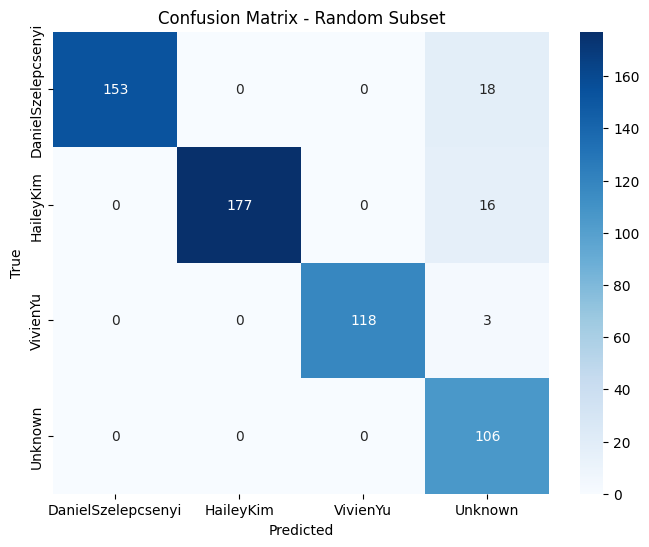

Known faces accuracy: 92.37%
False Acceptance Rate (FAR) on strangers: 0.00%


In [107]:
known_acc, far = evaluate_random_subset(known_dir, unknown_dir, recognizer, 
                                        known_people_count=3, unknown_videos_count=5)

print(f"Known faces accuracy: {known_acc*100:.2f}%")
print(f"False Acceptance Rate (FAR) on strangers: {far*100:.2f}%")